## BC Hydro EV Charging EDA

In [1]:
# Import core and specialist libraries
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# Preprocessing, metrics, clustering, PCA, t-SNE, and UMAP
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans, DBSCAN
import hdbscan
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.utils import resample
import umap

# Configure plotting styles and disable warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

print("Setup complete.")

/Users/timothykung/Desktop/Kung_Tim_Lab_Task/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete.


In [2]:
## Load datasets
df_sessions = pd.read_csv("data/sessions.csv")
df_consumption = pd.read_csv("data/consumption.csv")
df_authority_load = pd.read_csv("data/authority_load.csv")

## Sessions Exploration

EV charging sessions data provided by client.

In [3]:
df_sessions.describe()

,duration_hours,energy_kwh,peak_overlap_ratio,battery_soc_start
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,10.129367,25.012033,0.308508,42.904917
std,8.935858,8.054352,0.303486,18.385750
min,1.600000,11.000000,0.000000,10.000000
25%,4.630000,18.140000,0.000000,26.900000
50%,6.730000,24.950000,0.285000,43.050000
75%,11.760000,32.020000,0.470000,58.600000
max,67.650000,39.430000,1.000000,74.900000


In [4]:
df_sessions.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   session_id          1200 non-null   str    
 1   user_id             1200 non-null   str    
 2   housing_type        1200 non-null   str    
 3   charger_level       1200 non-null   str    
 4   start_time          1200 non-null   str    
 5   duration_hours      1200 non-null   float64
 6   energy_kwh          1200 non-null   float64
 7   peak_overlap_ratio  1200 non-null   float64
 8   season              1200 non-null   str    
 9   battery_soc_start   1200 non-null   float64
dtypes: float64(4), str(6)
memory usage: 173.4 KB


In [5]:
df_sessions.head(5)

,session_id,user_id,housing_type,charger_level,start_time,duration_hours,energy_kwh,peak_overlap_ratio,season,battery_soc_start
0,EV-10000,USR-1289,Townhouse,Level 1 (1.4kW),2025-08-14 10:38:00,12.51,17.30,0.42,Winter,60.5
1,EV-10001,USR-1153,Condo/Apartment,Level 2 (7.2kW),2025-07-21 18:49:00,9.99,35.35,0.23,Spring,19.3
2,EV-10002,USR-1086,Single-Family,Level 2 (7.2kW),2025-01-19 17:42:00,7.72,35.62,0.45,Spring,18.7
3,EV-10003,USR-1185,Single-Family,Level 2 (7.2kW),2025-12-01 18:57:00,49.23,14.02,0.19,Winter,68.0
4,EV-10004,USR-1043,Townhouse,Level 2 (7.2kW),2025-06-16 17:19:00,3.21,19.63,1.00,Fall,55.2


In [6]:
## Cleaning / Converting
df_sessions["start_time_datetime_conv"] = pd.to_datetime(df_sessions['start_time'])

In [7]:
df_sessions.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   session_id                1200 non-null   str           
 1   user_id                   1200 non-null   str           
 2   housing_type              1200 non-null   str           
 3   charger_level             1200 non-null   str           
 4   start_time                1200 non-null   str           
 5   duration_hours            1200 non-null   float64       
 6   energy_kwh                1200 non-null   float64       
 7   peak_overlap_ratio        1200 non-null   float64       
 8   season                    1200 non-null   str           
 9   battery_soc_start         1200 non-null   float64       
 10  start_time_datetime_conv  1200 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(4), str(6)
memory usage: 182.7 KB


In [8]:
grouped = df_sessions.groupby('start_time_datetime_conv').count()
grouped

,session_id,user_id,housing_type,charger_level,start_time,duration_hours,energy_kwh,peak_overlap_ratio,season,battery_soc_start
start_time_datetime_conv,,,,,,,,,,
2025-01-01 16:04:00,1,1,1,1,1,1,1,1,1,1
2025-01-01 17:12:00,1,1,1,1,1,1,1,1,1,1
2025-01-01 23:02:00,1,1,1,1,1,1,1,1,1,1
2025-01-02 17:01:00,1,1,1,1,1,1,1,1,1,1
2025-01-02 18:02:00,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...
2025-12-30 22:39:00,1,1,1,1,1,1,1,1,1,1
2025-12-31 00:38:00,1,1,1,1,1,1,1,1,1,1
2025-12-31 17:49:00,1,1,1,1,1,1,1,1,1,1


## 30-minute time-of-day aggregation

Bins sessions by time-of-day (ignoring calendar date) into 30-minute buckets to reveal the daily charging demand profile.

In [9]:
df_sessions["time_of_day_30min"] = df_sessions["start_time_datetime_conv"].dt.floor("30min").dt.time

agg_30min = (
    df_sessions.groupby("time_of_day_30min")
    .agg(
        session_count=("session_id", "count"),
        avg_duration_hours=("duration_hours", "mean"),
        avg_energy_kwh=("energy_kwh", "mean"),
        total_energy_kwh=("energy_kwh", "sum"),
        avg_peak_overlap_ratio=("peak_overlap_ratio", "mean"),
        avg_battery_soc_start=("battery_soc_start", "mean"),
    )
    .sort_index()
)

In [10]:
agg_30min.head(5)

,session_count,avg_duration_hours,avg_energy_kwh,total_energy_kwh,avg_peak_overlap_ratio,avg_battery_soc_start
time_of_day_30min,,,,,,
00:00:00,31,8.841290,23.928065,741.77,0.0,45.380645
00:30:00,28,8.414286,23.480000,657.44,0.0,46.403571
01:00:00,3,6.740000,17.113333,51.34,0.0,60.933333
01:30:00,2,5.535000,28.585000,57.17,0.0,34.750000
02:00:00,1,5.680000,14.110000,14.11,0.0,67.800000


### Scatter plots of 30-minute aggregates over time of day

Small multiples (one scatter per metric) since the five measures live on very
different scales (hours, kWh, a 0-1 ratio, and a percentage) — a single shared
y-axis would flatten most of them.

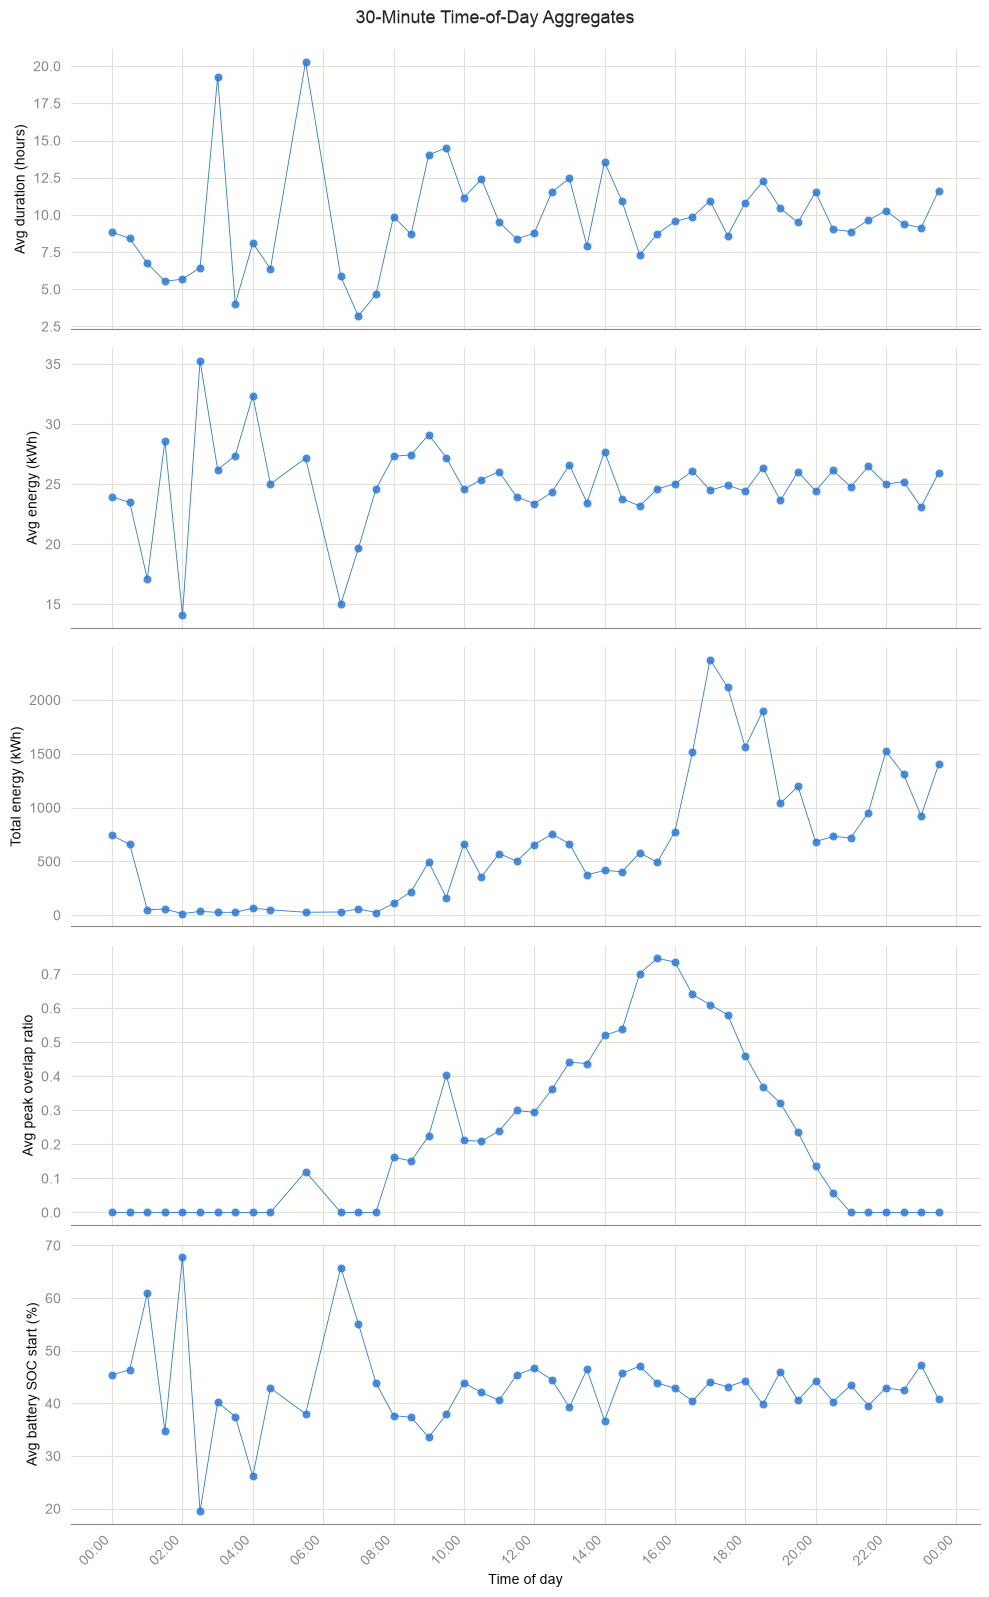

In [11]:
import matplotlib.dates as mdates

# Time-of-day index -> datetime on a dummy day, so matplotlib can treat it as a time axis
x = pd.to_datetime(agg_30min.index.astype(str))

metrics = [
    ("avg_duration_hours", "Avg duration (hours)"),
    ("avg_energy_kwh", "Avg energy (kWh)"),
    ("total_energy_kwh", "Total energy (kWh)"),
    ("avg_peak_overlap_ratio", "Avg peak overlap ratio"),
    ("avg_battery_soc_start", "Avg battery SOC start (%)"),
]

MARK_COLOR = "#2a78d6"
GRID_COLOR = "#e1e0d9"
MUTED = "#898781"

fig, axes = plt.subplots(len(metrics), 1, figsize=(10, 16), sharex=True)

for ax, (col, label) in zip(axes, metrics):
    ax.scatter(x, agg_30min[col], s=40, color=MARK_COLOR, alpha=0.85,
               edgecolor="white", linewidth=0.6, zorder=3)
    ax.plot(x, agg_30min[col], color=MARK_COLOR,linewidth=0.6, zorder=3)
    ax.set_ylabel(label, color="#0b0b0b")
    ax.grid(True, color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(MUTED)
    ax.tick_params(colors=MUTED)

axes[-1].xaxis.set_major_locator(mdates.HourLocator(interval=2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.setp(axes[-1].get_xticklabels(), rotation=45, ha="right")
axes[-1].set_xlabel("Time of day", color="#0b0b0b")

fig.suptitle("30-Minute Time-of-Day Aggregates", y=0.995, fontsize=13)
fig.tight_layout()
plt.show()

## Day of week and month

Derives calendar features from `start_time_datetime_conv` for later grouping/seasonality analysis.

In [12]:
df_sessions["day_of_week"] = df_sessions["start_time_datetime_conv"].dt.day_name()
df_sessions["month"] = df_sessions["start_time_datetime_conv"].dt.month_name()

df_sessions[["start_time_datetime_conv", "day_of_week", "month"]].head()

,start_time_datetime_conv,day_of_week,month
0,2025-08-14 10:38:00,Thursday,August
1,2025-07-21 18:49:00,Monday,July
2,2025-01-19 17:42:00,Sunday,January
3,2025-12-01 18:57:00,Monday,December
4,2025-06-16 17:19:00,Monday,June


### Total energy usage by month and by day of week

Bar charts of summed `energy_kwh`, with months in calendar order (January–December)
and days in weekday order (Monday–Sunday) rather than alphabetical or first-seen order.

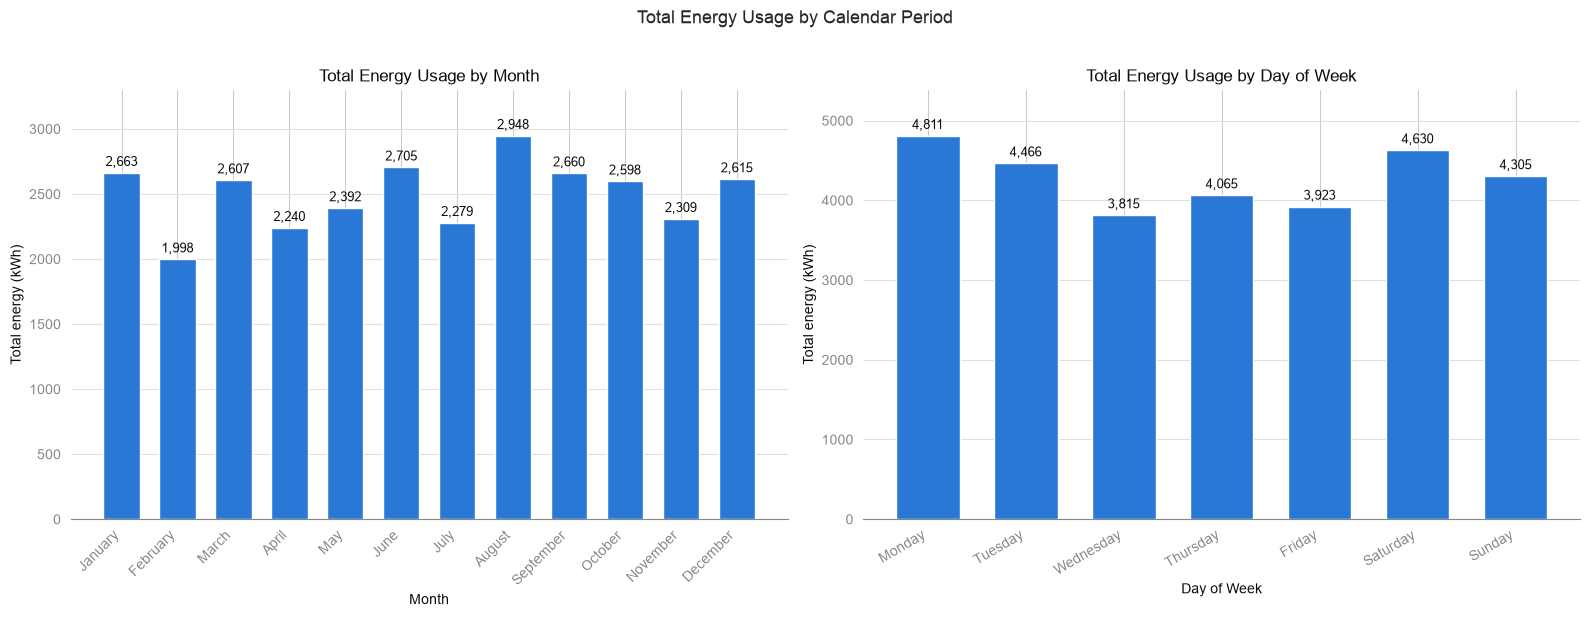

In [13]:
MONTH_ORDER = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December",
]
DAY_ORDER = [
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday",
]

energy_by_month = (
    df_sessions.groupby("month")["energy_kwh"].sum().reindex(MONTH_ORDER, fill_value=0)
)
energy_by_day = (
    df_sessions.groupby("day_of_week")["energy_kwh"].sum().reindex(DAY_ORDER, fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

panels = (
    (axes[0], energy_by_month, "Total Energy Usage by Month", "Month", 45),
    (axes[1], energy_by_day, "Total Energy Usage by Day of Week", "Day of Week", 30),
)

for ax, data, title, xlabel, rotation in panels:
    bars = ax.bar(data.index, data.values, color=MARK_COLOR, width=0.65, zorder=3)
    ax.bar_label(
        bars,
        labels=[f"{v:,.0f}" for v in data.values],
        padding=3, fontsize=9, color="#0b0b0b",
    )

    ax.set_title(title, fontsize=12, color="#0b0b0b")
    ax.set_xlabel(xlabel, color="#0b0b0b")
    ax.set_ylabel("Total energy (kWh)", color="#0b0b0b")
    ax.grid(True, axis="y", color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(MUTED)
    ax.tick_params(colors=MUTED)
    plt.setp(ax.get_xticklabels(), rotation=rotation, ha="right")
    ax.margins(y=0.12)  # headroom so data labels don't clip the top

fig.suptitle("Total Energy Usage by Calendar Period", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()

## Consumption Exploration

Consumption exploration sources by data science team (me, Tim K.) Sourced from: https://energy-information.canada.ca/en/subjects/electricity

The dataset has been already pre-filtered to limit results to BC geography. The column can be considered a dummy.

In [14]:
df_consumption.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Geography                48 non-null     str  
 1   Reference period         48 non-null     str  
 2   3 - value measure (MWh)  48 non-null     str  
dtypes: str(3)
memory usage: 3.3 KB


In [15]:
df_consumption.describe()

,Geography,Reference period,3 - value measure (MWh)
count,48,48,48
unique,1,48,48
top,British Columbia,2022-06-01 00:00:00,"4,261,299"
freq,48,1,1


In [16]:
df_consumption.head()

,Geography,Reference period,3 - value measure (MWh)
0,British Columbia,2022-06-01 00:00:00,"4,261,299"
1,British Columbia,2022-07-01 00:00:00,"4,415,055"
2,British Columbia,2022-08-01 00:00:00,"4,870,866"
3,British Columbia,2022-09-01 00:00:00,"4,465,966"
4,British Columbia,2022-10-01 00:00:00,"4,880,649"


## Authority Load Exploration

Balancing Authority Load Data sourced by data science team (Me, again, Tim K.) Sourced: https://www.bchydro.com/energy-in-bc/operations/transmission/transmission-system/balancing-authority-load-data.html


Columns Explained:

`Date` 
— the calendar date of the reading.


`HE (Hour Ending)` 
— the hour the load measurement corresponds to, expressed as the end of that hour. So "HE 14" means the reading covers the period from 1:00 pm to 2:00 pm. This convention (vs. "hour beginning") is standard in North American power industry reporting.


`Control Area Load`
— the actual measured electricity demand (measured in Megawatts) for that control area during that hour — i.e., the total power being drawn from the grid in BC Hydro's service territory at that hour.

In [17]:
df_authority_load.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Date               8760 non-null   str  
 1   HE                 8760 non-null   str  
 2   Control Area Load  8760 non-null   int64
dtypes: int64(1), str(2)
memory usage: 304.9 KB


In [18]:
df_authority_load.describe()

,Control Area Load
count,8760.000000
mean,7682.072831
std,1172.922864
min,5359.000000
25%,6896.750000
50%,7570.000000
75%,8475.000000
max,11359.000000


In [19]:
df_authority_load.head()

,Date,HE,Control Area Load
0,01/01/2025,1,7942
1,01/01/2025,2,7819
2,01/01/2025,3,7710
3,01/01/2025,4,7637
4,01/01/2025,5,7670


### Mean and median control area load by hour ending

Grouped bar chart comparing the mean and median `Control Area Load` for each
`HE` bucket (1–24), to see how the two central-tendency measures diverge across
the daily load curve.

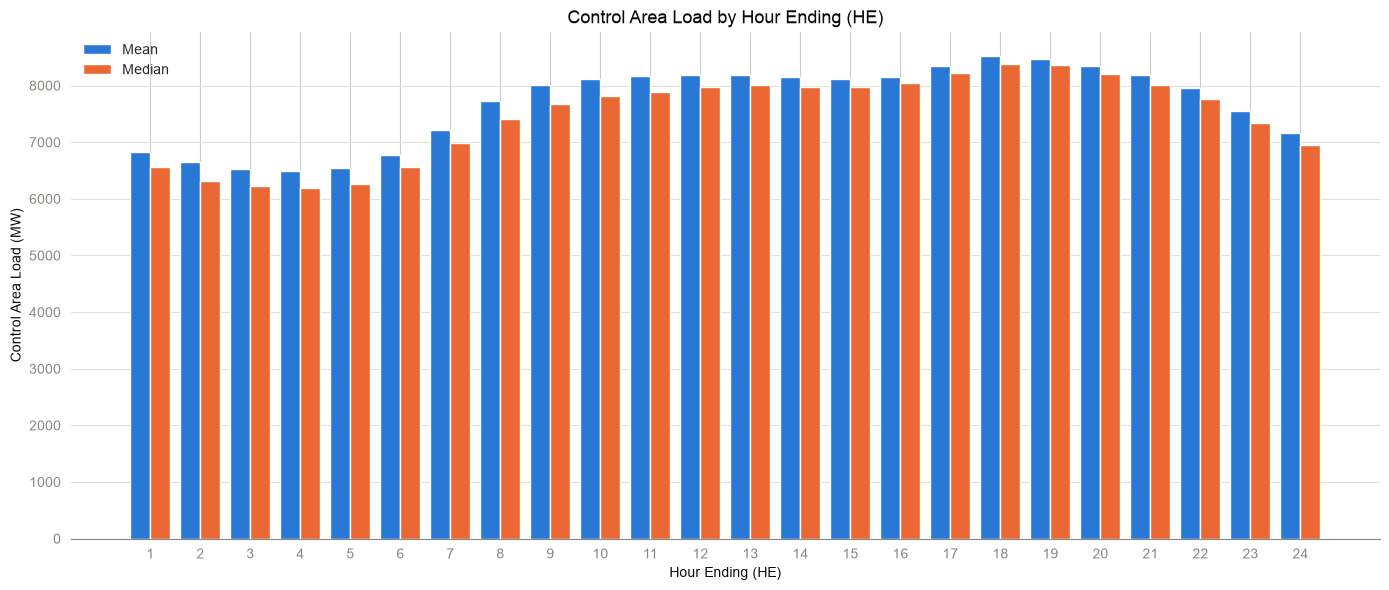

In [20]:
HE_ORDER = [str(h) for h in range(1, 25)]

he_stats = (
    df_authority_load.groupby("HE")["Control Area Load"]
    .agg(["mean", "median"])
    .reindex(HE_ORDER)
)

MEAN_COLOR = MARK_COLOR
MEDIAN_COLOR = "#eb6834"

x = np.arange(len(he_stats))
width = 0.4

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(x - width / 2, he_stats["mean"], width, label="Mean",
       color=MEAN_COLOR, zorder=3)
ax.bar(x + width / 2, he_stats["median"], width, label="Median",
       color=MEDIAN_COLOR, zorder=3)

ax.set_title("Control Area Load by Hour Ending (HE)", fontsize=13, color="#0b0b0b")
ax.set_xlabel("Hour Ending (HE)", color="#0b0b0b")
ax.set_ylabel("Control Area Load (MW)", color="#0b0b0b")
ax.set_xticks(x)
ax.set_xticklabels(he_stats.index)
ax.grid(True, axis="y", color=GRID_COLOR, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(MUTED)
ax.tick_params(colors=MUTED)
ax.legend(frameon=False, loc="upper left")

fig.tight_layout()
plt.show()

## Preliminary Clustering

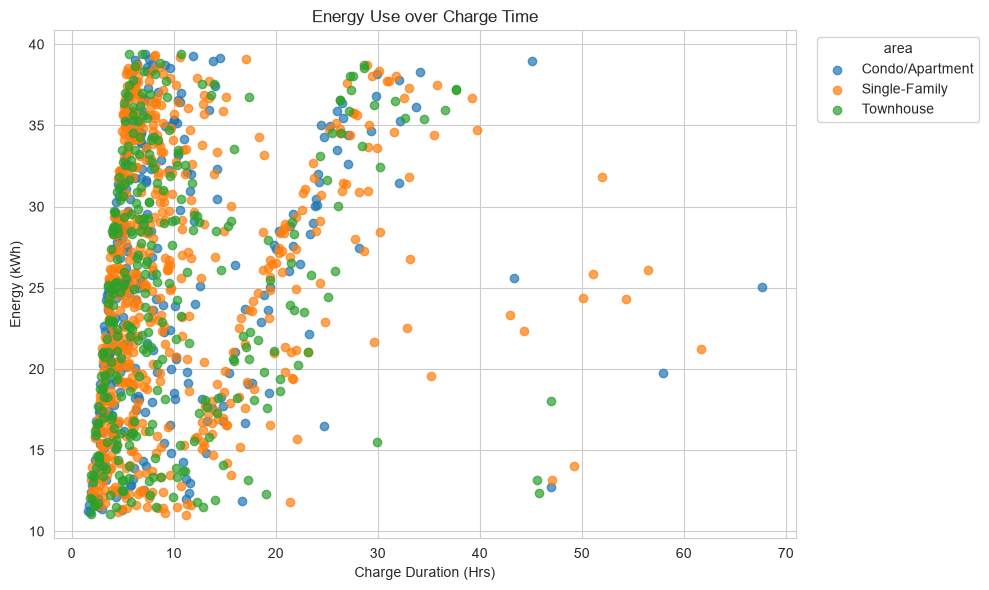

In [21]:
# create scatter plot of Longitude vs Latitude
# group data by Neighborhood and color each group differently
# add labels, legend, and show plot

plt.figure(figsize=(10, 6))
for area, group in df_sessions.groupby("housing_type"):
    lons = group["duration_hours"]
    lats = group["energy_kwh"]
    plt.scatter(lons, lats, label=area, alpha=0.7)

plt.xlabel("Charge Duration (Hrs)")
plt.ylabel("Energy (kWh)")
plt.title("Energy Use over Charge Time")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="area")
plt.tight_layout()
plt.show()

## Feature Engineering for Clustering

Builds a numeric feature matrix from `housing_type`, `charger_level`, `start_time`, `duration_hours`, `energy_kwh`, `peak_overlap_ratio`, `season`, and `battery_soc_start` so it can feed the PCA/t-SNE/UMAP and clustering steps below.

- `charger_level` is parsed into its rated kW (`charger_power_kw`) — a more informative numeric signal than the label itself.
- `start_time` is cyclically encoded as `start_hour_sin`/`start_hour_cos` so 23:00 and 00:00 land next to each other rather than at opposite ends of a linear scale, plus an `is_weekend` flag.
- `housing_type` and `season` are nominal, so they're one-hot encoded.
- Continuous fields are standardized afterward so no single scale dominates distance-based clustering.

In [22]:
FEATURE_COLUMNS = [
    "housing_type", "charger_level", "start_time", "duration_hours",
    "energy_kwh", "peak_overlap_ratio", "season", "battery_soc_start",
]

df_features = df_sessions[FEATURE_COLUMNS].copy()

# Charger power (kW) parsed out of the label, e.g. "Level 2 (7.2kW)" -> 7.2
df_features["charger_power_kw"] = (
    df_features["charger_level"].str.extract(r"\(([\d.]+)kW\)").astype(float)
)

# Cyclical encoding of time-of-day so hours near midnight stay close together, plus a weekend flag
start_dt = pd.to_datetime(df_features["start_time"])
hour_frac = start_dt.dt.hour + start_dt.dt.minute / 60
df_features["start_hour_sin"] = np.sin(2 * np.pi * hour_frac / 24)
df_features["start_hour_cos"] = np.cos(2 * np.pi * hour_frac / 24)
df_features["is_weekend"] = start_dt.dt.dayofweek.isin([5, 6]).astype(int)

# One-hot encode the nominal categoricals
df_features = pd.get_dummies(
    df_features, columns=["housing_type", "season"], prefix=["housing", "season"], dtype=int
)

# Drop source columns now that they've been encoded
df_features = df_features.drop(columns=["charger_level", "start_time"])

df_features.head()

,duration_hours,energy_kwh,peak_overlap_ratio,battery_soc_start,charger_power_kw,start_hour_sin,start_hour_cos,is_weekend,housing_Condo/Apartment,housing_Single-Family,housing_Townhouse,season_Fall,season_Spring,season_Summer,season_Winter
0,12.51,17.30,0.42,60.5,1.4,0.350207,-0.936672,0,0,0,1,0,0,0,1
1,9.99,35.35,0.23,19.3,7.2,-0.977231,0.212178,0,1,0,0,0,1,0,0
2,7.72,35.62,0.45,18.7,7.2,-0.996917,-0.078459,1,0,1,0,0,1,0,0
3,49.23,14.02,0.19,68.0,7.2,-0.969231,0.246153,0,0,1,0,0,0,0,1
4,3.21,19.63,1.00,55.2,7.2,-0.984041,-0.177944,0,0,0,1,1,0,0,0


In [23]:
CONTINUOUS_COLUMNS = [
    "duration_hours", "energy_kwh", "peak_overlap_ratio", "battery_soc_start",
    "charger_power_kw", "start_hour_sin", "start_hour_cos",
]

scaler = StandardScaler()
df_features_scaled = df_features.copy()
df_features_scaled[CONTINUOUS_COLUMNS] = scaler.fit_transform(df_features[CONTINUOUS_COLUMNS])

# Numeric feature matrix ready for PCA / t-SNE / UMAP and clustering
X = df_features_scaled.values
df_features_scaled.head()

,duration_hours,energy_kwh,peak_overlap_ratio,battery_soc_start,charger_power_kw,start_hour_sin,start_hour_cos,is_weekend,housing_Condo/Apartment,housing_Single-Family,housing_Townhouse,season_Fall,season_Spring,season_Summer,season_Winter
0,0.266525,-0.957898,0.367523,0.957395,-2.059168,1.756537,-1.472097,0,0,0,1,0,0,0,1
1,-0.015603,1.284061,-0.258796,-1.284405,0.485633,-0.909316,0.200986,0,1,0,0,0,1,0,0
2,-0.269741,1.317597,0.466416,-1.317053,0.485633,-0.948851,-0.222272,1,0,1,0,0,1,0,0
3,4.377524,-1.365301,-0.390653,1.365489,0.485633,-0.893249,0.250465,0,0,1,0,0,0,0,1
4,-0.774660,-0.668493,2.279446,0.669008,0.485633,-0.922991,-0.367152,0,0,0,1,1,0,0,0


### Correlation Matrix

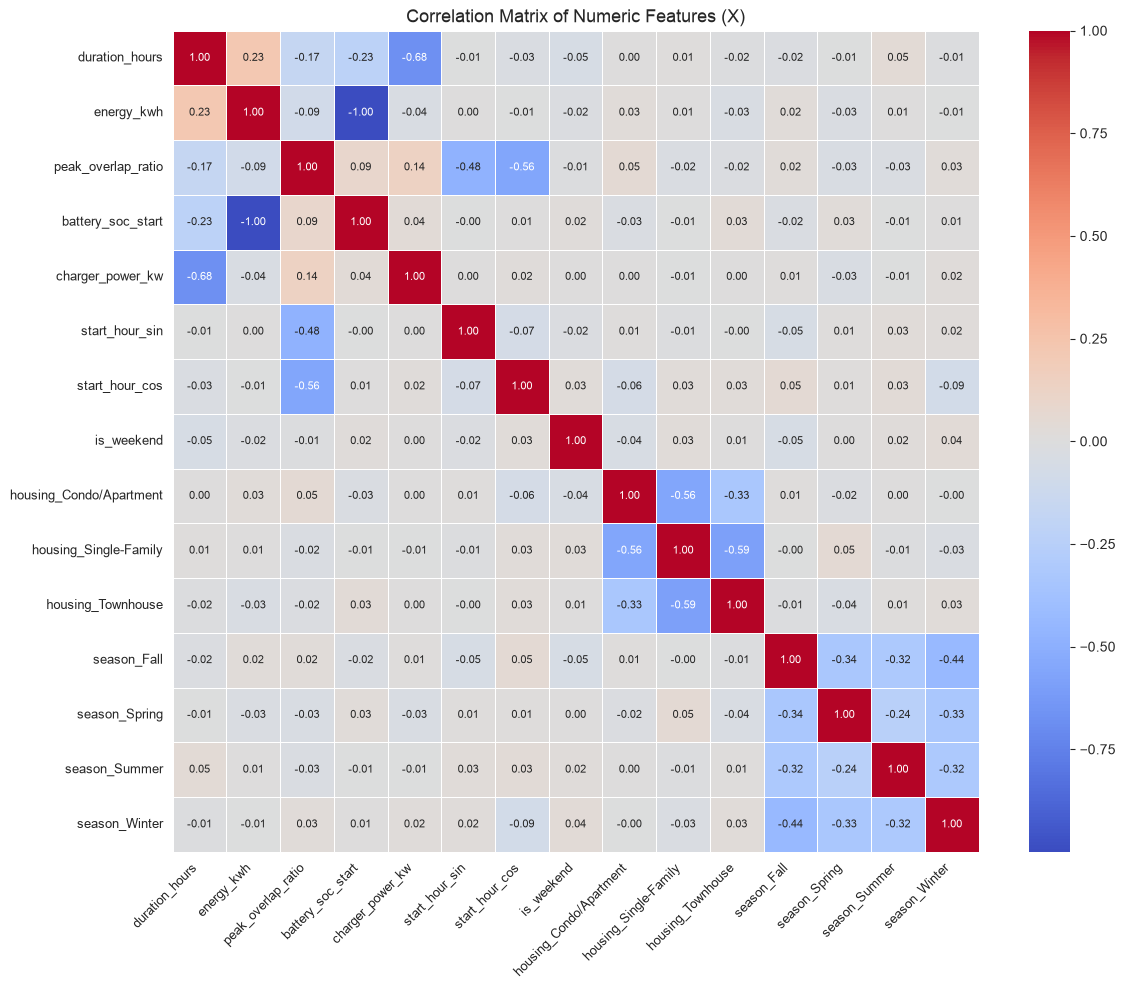

In [24]:
# Correlation matrix of numeric features
corr = df_features_scaled.corr()

# Plot as heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Correlation Matrix of Numeric Features (X)', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

## Clustering

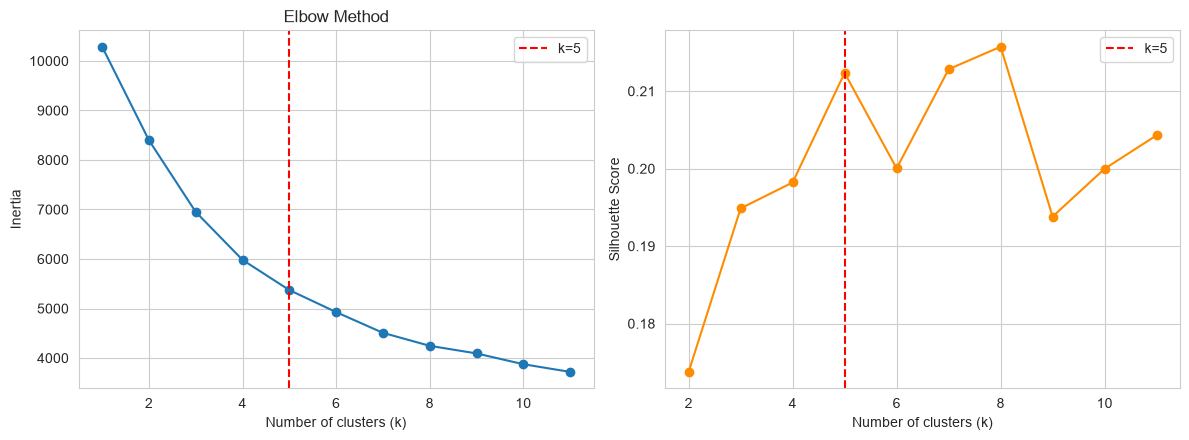

In [25]:
k_max = 12

inertias = []
for k in range(1, k_max):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

silhouette_scores = {}
for k in range(2, k_max):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km_labels = km.fit_predict(X)
    silhouette_scores[k] = silhouette_score(X, km_labels)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].plot(range(1, k_max), inertias, marker="o")
ax[0].set_xlabel("Number of clusters (k)")
ax[0].set_ylabel("Inertia")
ax[0].set_title("Elbow Method")
ax[0].axvline(x=5, color="red", linestyle="--", label="k=5")
ax[0].legend()

ax[1].plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker="o", color="darkorange")
ax[1].set_xlabel("Number of clusters (k)")
ax[1].set_ylabel("Silhouette Score")
ax[1].axvline(x=5, color="red", linestyle="--", label="k=5")
ax[1].legend()

plt.tight_layout()
plt.show()

The inertia curve declines smoothly with no sharp elbow — expected given the mix of continuous session metrics and one-hot housing/season dummies. Silhouette score is fairly flat and low overall (0.17–0.22, indicating weak/overlapping cluster structure), but it peaks locally at **k=5** (0.212) before dipping and re-peaking around k=7–8 (~0.21–0.22). I go with k=5: it sits on a local silhouette maximum while staying more interpretable than the 7–8 cluster solutions, which mostly just splinter the same profiles into smaller pieces rather than revealing a genuinely new group.

#### Plotting KMeans with Optimal K

Here, I fit KMeans with the chosen k=5 and inspect what each cluster actually represents.

In [26]:
kmeans_final = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10)
df_sessions["KMeans_Cluster"] = kmeans_final.fit_predict(X)
df_features["KMeans_Cluster"] = df_sessions["KMeans_Cluster"]

df_sessions["KMeans_Cluster"].value_counts().sort_index()

KMeans_Cluster
0    223
1    305
2    266
3    167
4    239
Name: count, dtype: int64

#### Cluster Profiles

A quick sanity check on what each cluster actually represents: mean charging behaviour per cluster, plus how each cluster breaks down by `housing_type` and `season`.

In [27]:
profile_cols = ["duration_hours", "energy_kwh", "peak_overlap_ratio", "battery_soc_start", "charger_power_kw"]

cluster_profile = df_features.groupby("KMeans_Cluster")[profile_cols].mean().round(2)
cluster_profile["n"] = df_sessions["KMeans_Cluster"].value_counts().sort_index()
cluster_profile

,duration_hours,energy_kwh,peak_overlap_ratio,battery_soc_start,charger_power_kw,n
KMeans_Cluster,,,,,,
0,24.80,26.27,0.23,40.04,1.74,223
1,8.11,33.41,0.29,23.72,7.20,305
2,5.16,19.45,0.70,55.59,7.18,266
3,7.39,24.56,0.23,43.94,6.99,167
4,6.46,19.62,0.03,55.21,6.91,239


In [28]:
# Do housing_type / season line up with the clusters, or are they irrelevant to how sessions group?
display(pd.crosstab(df_sessions["KMeans_Cluster"], df_sessions["housing_type"], normalize="index").round(2))
display(pd.crosstab(df_sessions["KMeans_Cluster"], df_sessions["season"], normalize="index").round(2))

housing_type,Condo/Apartment,Single-Family,Townhouse
KMeans_Cluster,,,
0,0.25,0.50,0.26
1,0.20,0.52,0.27
2,0.29,0.46,0.25
3,0.29,0.49,0.23
4,0.20,0.52,0.28


season,Fall,Spring,Summer,Winter
KMeans_Cluster,,,,
0,0.29,0.22,0.21,0.28
1,0.33,0.20,0.17,0.30
2,0.34,0.18,0.17,0.31
3,0.24,0.17,0.18,0.41
4,0.30,0.23,0.22,0.25


The 5 clusters are entirely defined by *charging behaviour*, not by who the driver is or when in the year they charged:

- **Cluster 0** (n=223) — long duration (~24.8h), Level 1 charger (~1.7kW), low peak overlap (~0.23), mid battery start (~40%) — **overnight Level-1 charging**.
- **Cluster 1** (n=305) — short duration (~8.1h), Level 2 (~7.2kW), highest energy delivered (~33.4kWh), low battery start (~23.7%) — **fast top-up from a near-empty battery**.
- **Cluster 2** (n=266) — shortest duration (~5.2h), Level 2, highest peak overlap (~0.70), high battery start (~55.6%) — **peak-hour top-up despite an already-charged battery**.
- **Cluster 3** (n=167) — Level 2, moderate duration/energy, low peak overlap (~0.23) — **routine off-peak Level-2 charging**.
- **Cluster 4** (n=239) — Level 2, high battery start (~55.2%), lowest peak overlap of all (~0.03) — **off-peak top-up, minimal grid-peak impact**.

The `housing_type` and `season` breakdowns above are nearly identical to the dataset's overall base rates in every cluster (~50/24/26% Single-Family/Condo/Townhouse, ~25-30% per season) — neither feature meaningfully separates the clusters. So unlike a location- or demographic-driven segmentation, this clustering is purely about *when and how fast* a session charges and *how full the battery already was*, regardless of where the driver lives or the time of year.

### PCA Projection to 2D

`X` has 15 dimensions (7 scaled numeric + `is_weekend` + 3 housing dummies + 4 season dummies), too many to plot directly. PCA compresses it to the 2 directions of greatest variance so the clusters can be visualized on a scatter plot.

Explained variance: PC1=25.8%, PC2=19.8%, total=45.7%


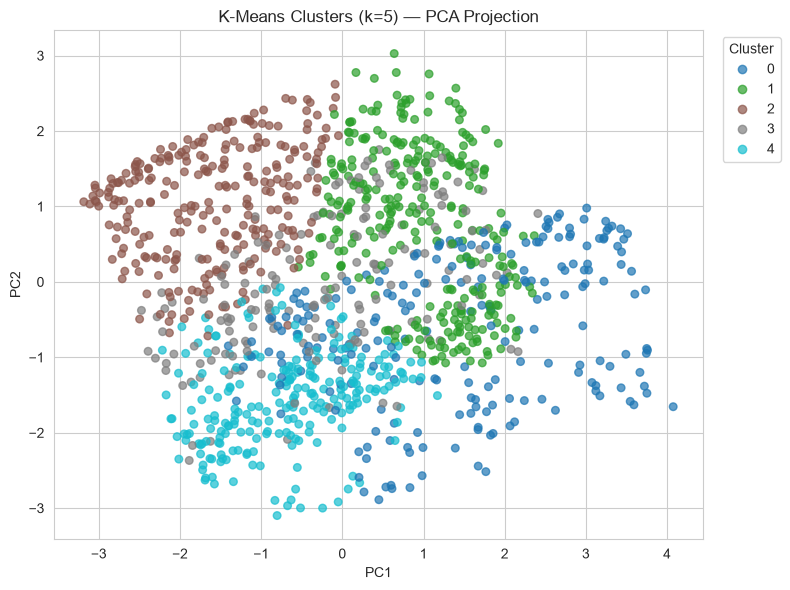

In [29]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)

print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.1%}, total={pca.explained_variance_ratio_.sum():.1%}")

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_sessions["KMeans_Cluster"], cmap="tab10", alpha=0.7, s=30)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters (k=5) — PCA Projection")
plt.legend(*scatter.legend_elements(), title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Evaluating: DBSCAN

For `min_samples` I use 15 — roughly the dimensionality of the 15-column feature matrix `X`, following the common minPts ≈ D+1 rule of thumb for higher-dimensional DBSCAN. `eps` is chosen from the k-distance plot below.

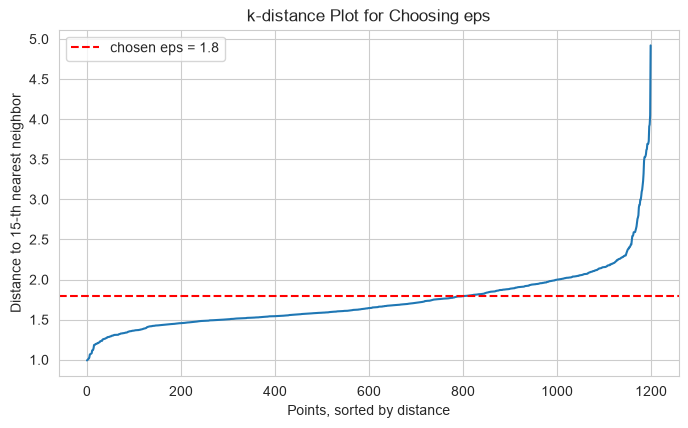

In [30]:
min_samples = 15

neighbours_model = NearestNeighbors(n_neighbors=min_samples)
neighbours_model.fit(X)
distances, _ = neighbours_model.kneighbors(X)

k_distances = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(k_distances)
ax.axhline(1.8, color="red", linestyle="--", label="chosen eps = 1.8")
ax.set_xlabel("Points, sorted by distance")
ax.set_ylabel(f"Distance to {min_samples}-th nearest neighbor")
ax.set_title("k-distance Plot for Choosing eps")
ax.legend()
plt.show()

The curve rises gradually rather than showing one sharp knee — a symptom of the feature matrix containing a strong near-binary split (`charger_power_kw` only takes two values, 1.4 vs 7.2 kW) layered under smoother continuous variation. I swept `eps` from 1.6–2.5 and found the cluster count is stable at 2 across the whole range; the choice mostly trades off noise fraction against cluster purity. I settle on **eps=1.8**, which sits just past the initial knee and keeps noise to a moderate ~12% of rows without over-merging the two dense cores.

In [31]:
dbscan = DBSCAN(eps=1.8, min_samples=min_samples)
df_sessions["DBSCAN_Cluster"] = dbscan.fit_predict(X)
df_features["DBSCAN_Cluster"] = df_sessions["DBSCAN_Cluster"]

n_clusters_dbscan = len(set(df_sessions["DBSCAN_Cluster"])) - (1 if -1 in df_sessions["DBSCAN_Cluster"].values else 0)
n_noise_dbscan = (df_sessions["DBSCAN_Cluster"] == -1).sum()
print(f"Number of clusters: {n_clusters_dbscan} and number of noise points: {n_noise_dbscan} (out of {len(df_sessions)} rows)")

df_sessions.groupby("DBSCAN_Cluster")["charger_level"].value_counts(normalize=True).round(2)

Number of clusters: 2 and number of noise points: 142 (out of 1200 rows)


DBSCAN_Cluster  charger_level  
-1              Level 1 (1.4kW)    0.63
                Level 2 (7.2kW)    0.37
 0              Level 2 (7.2kW)    1.00
 1              Level 1 (1.4kW)    1.00
Name: proportion, dtype: float64

In [32]:
dbscan_profile = df_features.groupby("DBSCAN_Cluster")[profile_cols].mean().round(2)
dbscan_profile["n"] = df_sessions["DBSCAN_Cluster"].value_counts().sort_index()
dbscan_profile

,duration_hours,energy_kwh,peak_overlap_ratio,battery_soc_start,charger_power_kw,n
DBSCAN_Cluster,,,,,,
-1,22.28,24.53,0.22,44.01,3.52,142
0,6.47,24.94,0.34,43.08,7.20,919
1,21.90,26.01,0.20,40.64,1.40,139


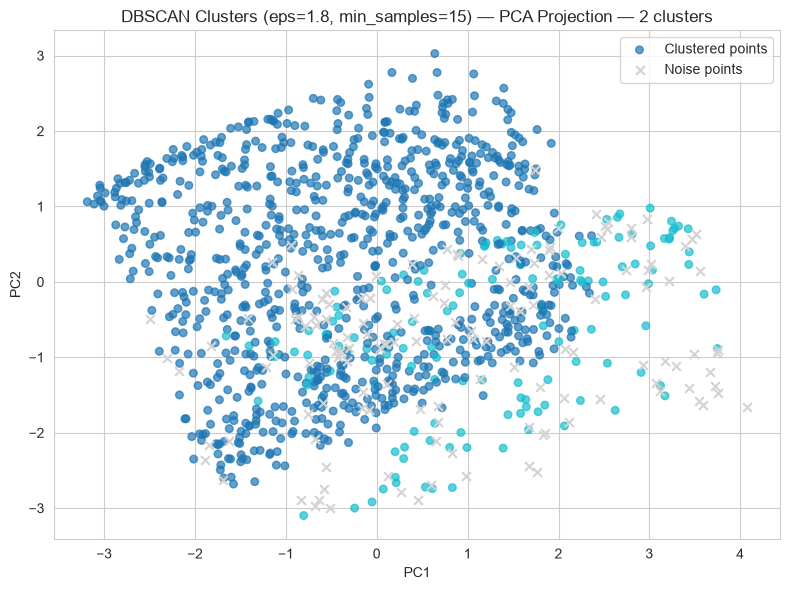

In [33]:
noise_mask = df_sessions["DBSCAN_Cluster"] == -1

plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[~noise_mask, 0], X_pca[~noise_mask, 1],
    c=df_sessions.loc[~noise_mask, "DBSCAN_Cluster"], cmap="tab10", alpha=0.7, s=30, label="Clustered points",
)
plt.scatter(
    X_pca[noise_mask, 0], X_pca[noise_mask, 1],
    c="lightgrey", marker="x", s=40, label="Noise points",
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"DBSCAN Clusters (eps=1.8, min_samples={min_samples}) — PCA Projection — {n_clusters_dbscan} clusters")
plt.legend()
plt.tight_layout()
plt.show()

### Write-up — KMeans vs. DBSCAN

DBSCAN (min_samples=15, eps=1.8) finds exactly **2 clusters** and **142 noise points (~11.8%)**, and those 2 clusters map almost perfectly onto `charger_level`: cluster 0 is 100% Level 2 sessions (mean duration ~6.5h, energy ~24.9kWh, peak overlap ~0.34) and cluster 1 is 100% Level 1 sessions (mean duration ~21.9h — consistent with Level 1's much slower charge rate, energy ~26.0kWh, peak overlap ~0.20). The noise points are a mix of both charger types (~63% Level 1 / 37% Level 2) — sessions whose duration/peak-overlap/battery combination doesn't fit the dense core for their charger type (e.g. an unusually short Level 1 session, or an unusually long Level 2 one).

This is a very different partition from KMeans' 5-way split, and it traces back to what each algorithm actually optimizes for. KMeans partitions all 1,200 sessions into k roughly-equal-variance groups regardless of density, so it's free to carve out finer behavioural distinctions — fast top-up vs. peak-hour top-up vs. off-peak charging — that only differ by a modest margin in continuous features like `peak_overlap_ratio` and `battery_soc_start`. DBSCAN instead looks for density-connected regions, and the single sharpest density boundary in this 15-dimensional feature space is the technological one: `charger_power_kw` only takes two values (1.4 vs 7.2 kW), so it splits the data into two unmistakably separate density cores before any of KMeans' softer behavioural distinctions get a chance to matter. DBSCAN's noise points represent sessions that are genuine behavioural outliers *elative to their own charger type. I argue this is the kind of point KMeans has no way to flag, since every session is forced into one of its 5 centroids no matter how atypical it is.

Both methods agree that `housing_type` and `season` are essentially irrelevant to how sessions cluster — neither the KMeans profile crosstabs nor the DBSCAN charger-level split shows any meaningful skew away from the dataset's overall housing/season base rates. In short: KMeans answers "what behavioural archetypes exist among charging sessions?", while DBSCAN answers a coarser question — "is this session part of the dominant Level-1 or Level-2 charging pattern, or is it an outlier?" — and treats charger hardware rather than driver behaviour as the dominant signal in the feature space.